In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("C:/Users/500hp/store-sales-retail-forcasting/data/train.csv")


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [14]:
df["date"].min(), df["date"].max()

('2013-01-01', '2017-08-15')

In [15]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [16]:
daily_sales = df.groupby("date")["sales"].sum()

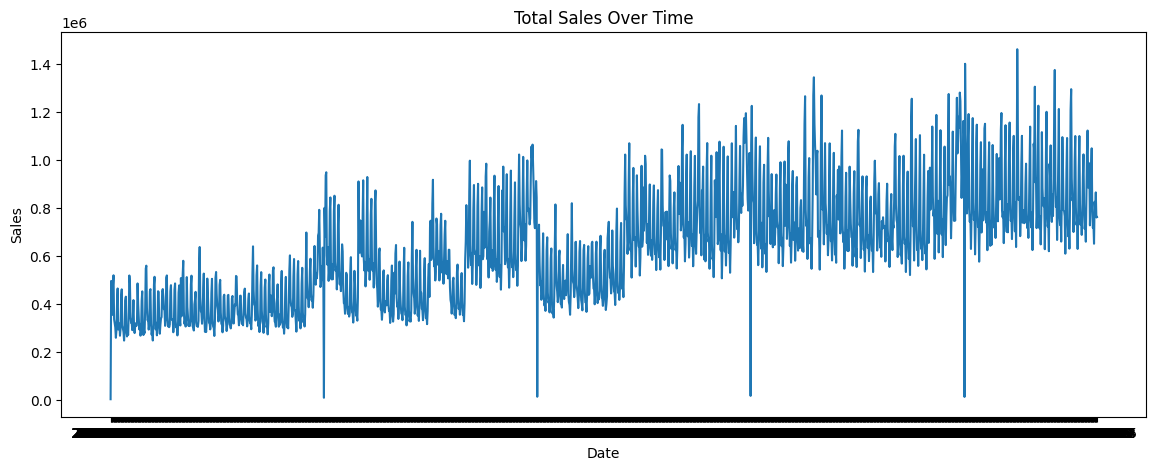

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [ ]:
#Plot rows where store is 1 and family is grocery 1
single_series = df[
    (df["store_nbr"] == 1) &
    (df["family"] == "GROCERY I")
]

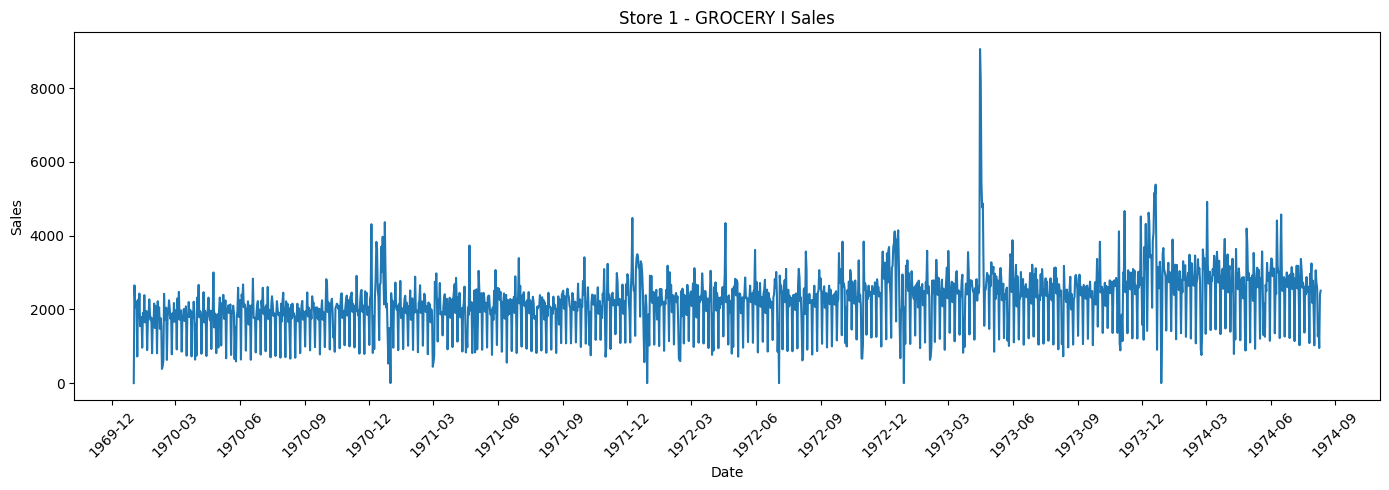

In [24]:
import matplotlib.dates as mdates

plt.figure(figsize=(14, 5))

plt.plot(single_series["date"], single_series["sales"])

plt.title("Store 1 - GROCERY I Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Is the repeating pattern caused by weekday behavior?

In [28]:
single_series["date"] = pd.to_datetime(single_series["date"])

In [29]:
single_series = single_series.copy()

single_series["day_of_week"] = single_series["date"].dt.day_name()

weekday_sales = (
    single_series
    .groupby("day_of_week")["sales"]
    .mean()
)

weekday_sales

day_of_week
Friday       2413.645833
Monday       2383.493776
Saturday     2322.962656
Sunday       1031.075000
Thursday     2229.045833
Tuesday      2408.991736
Wednesday    2770.362500
Name: sales, dtype: float64

In [30]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(day_order)

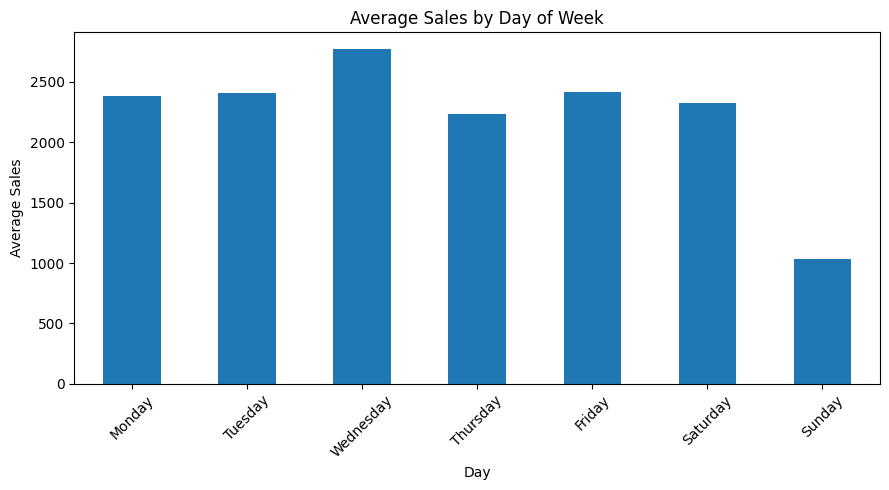

In [31]:
plt.figure(figsize=(9, 5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()